In [1]:
# Cell 1 — Importing the libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Loading RFM data
rfm = pd.read_csv("rfm_scores.csv")
print(rfm.shape)
rfm.head()

(5878, 9)


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,12346.0,326,12,77556.46,2,5,5,255,At Risk
1,12347.0,2,8,5633.32,5,4,5,545,Champions
2,12348.0,75,5,2019.40,3,4,4,344,Loyal Customers
3,12349.0,19,4,4428.69,5,3,5,535,Loyal Customers
4,12350.0,310,1,334.40,2,1,2,212,Lost


In [3]:
# Creating churn Label
rfm["churn"] = rfm["segment"].apply(
    lambda x: 1 if x in ["Lost", "At Risk"] else 0
)
print(rfm["churn"].value_counts())
print("\nChurn Rate:", round(rfm["churn"].mean() * 100, 2), "%")

churn
0    3779
1    2099
Name: count, dtype: int64

Churn Rate: 35.71 %


In [4]:
X = rfm[["recency", "frequency", "monetary"]]
y = rfm["churn"]
print("Features shape:", X.shape)

Features shape: (5878, 3)


In [5]:
# Spliting Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4702, 3)
Test size: (1176, 3)


In [6]:
# Training the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [7]:
# Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       750
           1       1.00      0.99      1.00       426

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



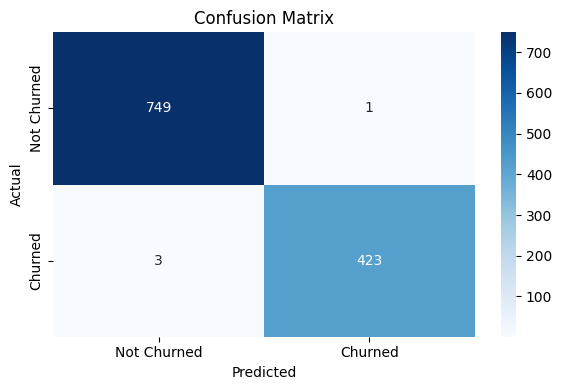

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Churned", "Churned"],
            yticklabels=["Not Churned", "Churned"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

     feature  importance
0    recency    0.727084
2   monetary    0.155923
1  frequency    0.116993


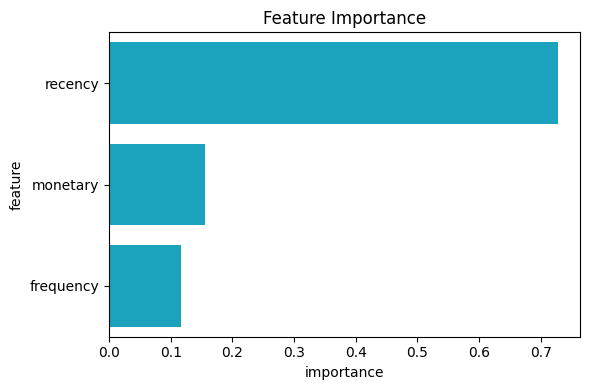

In [9]:
#  Feature Importance
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

plt.figure(figsize=(6,4))
sns.barplot(data=feature_importance, x="importance", y="feature", color="#00B4D8")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()


In [10]:
# saving the prediction
rfm["churn_predicted"] = model.predict(X)
rfm["churn_probability"] = model.predict_proba(X)[:, 1]
rfm.to_csv("rfm_with_churn.csv", index=False)
print("Saved!")

Saved!
